# Zadanie 3 – Klasyfikacja CIFAR-10 (MLP)

## Importy i konfiguracja

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

os.makedirs('plots', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']


device: cpu


## 1. Analiza danych

CIFAR-10: 50 000 obrazów treningowych i 10 000 testowych, 10 klas, rozmiar 32x32x3.

In [5]:
transform = transforms.ToTensor()
train_data = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform)

print('Rozmiar treningowy:', len(train_data))
print('Rozmiar testowy:   ', len(test_data))
print('Wymiary obrazu:    ', train_data[0][0].shape)
print(f'Zakres wartości:    [{train_data[0][0].min():.1f}, {train_data[0][0].max():.1f}]')


Rozmiar treningowy: 50000
Rozmiar testowy:    10000
Wymiary obrazu:     torch.Size([3, 32, 32])
Zakres wartości:    [0.0, 1.0]


### Rozkład klas

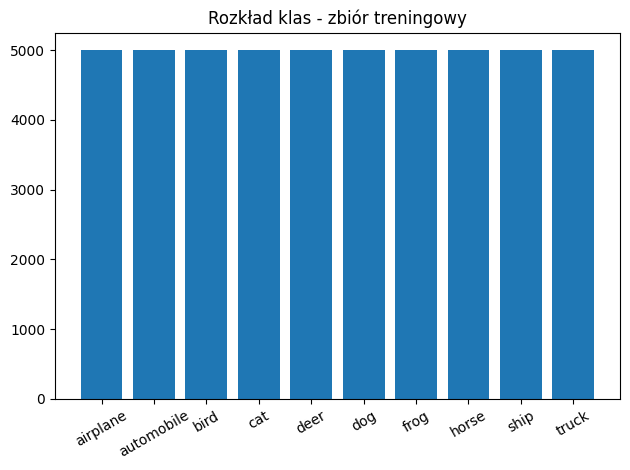

In [6]:
counts = [0] * 10
for _, y in train_data:
    counts[y] += 1

plt.bar(CLASSES, counts)
plt.title('Rozkład klas - zbiór treningowy')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/klasy.png')
plt.show()


Każda klasa ma 5000 przykladów – zbiór jest zbalansowany.

### Przykładowe obrazy

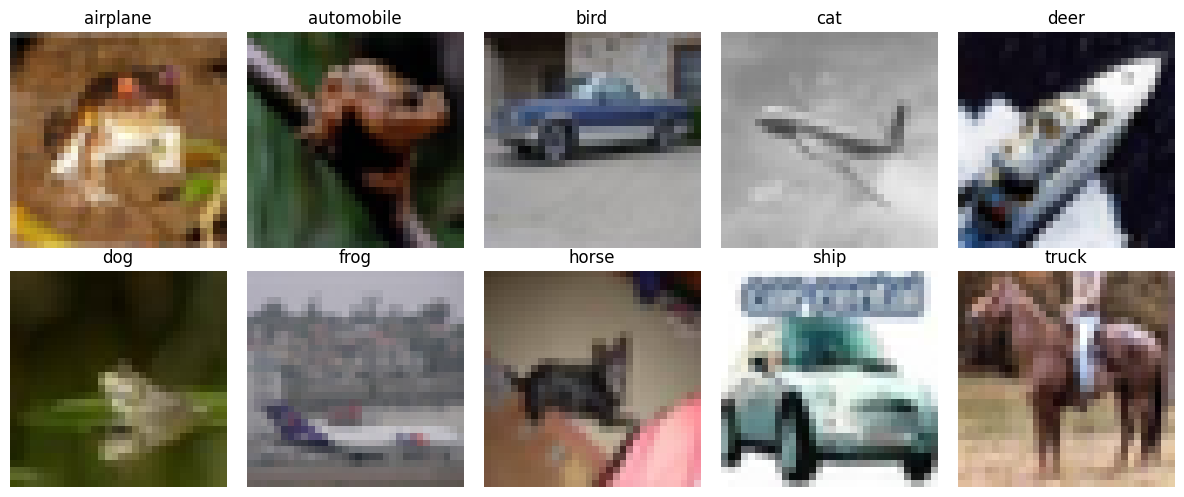

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, _ = train_data[i * 5000]
    axes[i//5][i%5].imshow(img.permute(1,2,0))
    axes[i//5][i%5].set_title(CLASSES[i])
    axes[i//5][i%5].axis('off')
plt.tight_layout()
plt.savefig('plots/przyklady.png')
plt.show()


### Statystyki pikseli

In [8]:
imgs = torch.stack([img for img, _ in train_data])
print(f'min: {imgs.min():.2f}, max: {imgs.max():.2f}')
print(f'mean (R,G,B): {imgs[:,0].mean():.4f}, {imgs[:,1].mean():.4f}, {imgs[:,2].mean():.4f}')
print(f'std  (R,G,B): {imgs[:,0].std():.4f},  {imgs[:,1].std():.4f},  {imgs[:,2].std():.4f}')


min: 0.00, max: 1.00
mean (R,G,B): 0.4914, 0.4822, 0.4465
std  (R,G,B): 0.2470,  0.2435,  0.2616


## 2. Model MLP

Obraz spłaszczany przed siecią: 3x32x32 = 3072 wejść.
Architektura: Linear → ReLU → [Dropout] → ... → Linear(10)
Funkcja straty: CrossEntropyLoss, optymalizator: Adam.

In [10]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[512, 256, 128], dropout=0.0):
        super().__init__()
        layers = []
        in_size = 3 * 32 * 32
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_size = h
        layers.append(nn.Linear(in_size, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        return self.net(x)

print(MLP())


MLP(
  (net): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 3. Trening i ewaluacja

In [11]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

def get_loaders(batch_size=64):
    t = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
    tr = torchvision.datasets.CIFAR10('./data', True,  download=True, transform=t)
    te = torchvision.datasets.CIFAR10('./data', False, download=True, transform=t)
    return DataLoader(tr, batch_size, shuffle=True), DataLoader(te, batch_size)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct    += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


## 4. Eksperymenty

### Seria 1 – Wpływ learning rate

Testuje wartości: 0.0001, 0.001, 0.01, 0.1. Pozostale parametry stałe: batch=64, hidden=[512,256,128].

In [12]:
lr_values = [0.0001, 0.001, 0.01, 0.1]
lr_results = {}

for lr in lr_values:
    print(f'lr = {lr}')
    train_loader, test_loader = get_loaders(64)
    model     = MLP([512, 256, 128]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    val_acc_hist = []
    for epoch in range(20):
        train_epoch(model, train_loader, criterion, optimizer)
        _, va = eval_epoch(model, test_loader, criterion)
        val_acc_hist.append(va)

    lr_results[lr] = val_acc_hist
    print(f'  max val acc: {max(val_acc_hist):.4f}')


lr = 0.0001
  max val acc: 0.5492
lr = 0.001
  max val acc: 0.5443
lr = 0.01
  max val acc: 0.2717
lr = 0.1
  max val acc: 0.1000


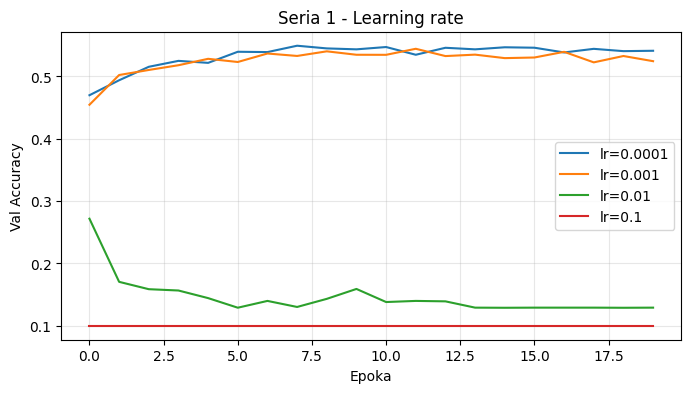

,lr,max_val_acc
0,0.0001,0.5492
1,0.0010,0.5443
2,0.0100,0.2717
3,0.1000,0.1000


In [13]:
plt.figure(figsize=(8, 4))
for lr in lr_values:
    plt.plot(lr_results[lr], label=f'lr={lr}')
plt.title('Seria 1 - Learning rate')
plt.xlabel('Epoka'); plt.ylabel('Val Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('plots/exp_lr.png'); plt.show()

display(pd.DataFrame({'lr': lr_values,
                      'max_val_acc': [round(max(lr_results[lr]), 4) for lr in lr_values]}))


**Wniosek:** lr=0.0001 daje najlepsze wyniki. lr = 0.1 daje najgorszy wynik a zatem lepsza jest powolna nauka.

### Seria 2 – Wpływ batch size

Testuje: 16, 32, 64, 128. lr=0.0001, hidden=[512,256,128].

In [16]:
batch_values = [16, 32, 64, 128]
bs_results = {}

for bs in batch_values:
    print(f'batch_size = {bs}')
    train_loader, test_loader = get_loaders(bs)
    model     = MLP([512, 256, 128]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    val_acc_hist = []
    for epoch in range(20):
        train_epoch(model, train_loader, criterion, optimizer)
        _, va = eval_epoch(model, test_loader, criterion)
        val_acc_hist.append(va)

    bs_results[bs] = val_acc_hist
    print(f'  max val acc: {max(val_acc_hist):.4f}')


batch_size = 16
  max val acc: 0.5521
batch_size = 32
  max val acc: 0.5566
batch_size = 64
  max val acc: 0.5527
batch_size = 128
  max val acc: 0.5503


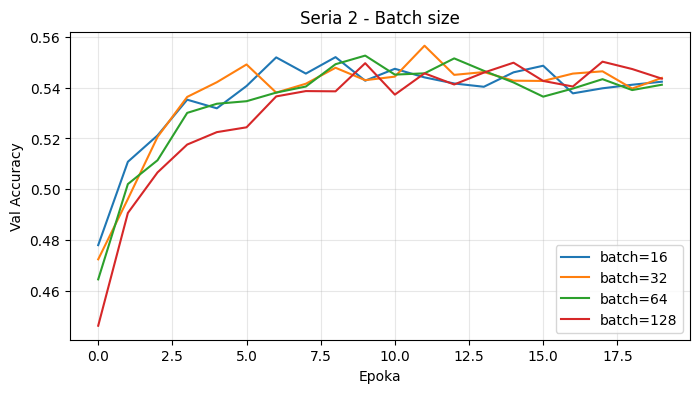

,batch_size,max_val_acc
0,16,0.5521
1,32,0.5566
2,64,0.5527
3,128,0.5503


In [17]:
plt.figure(figsize=(8, 4))
for bs in batch_values:
    plt.plot(bs_results[bs], label=f'batch={bs}')
plt.title('Seria 2 - Batch size')
plt.xlabel('Epoka'); plt.ylabel('Val Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('plots/exp_bs.png'); plt.show()

display(pd.DataFrame({'batch_size': batch_values,
                      'max_val_acc': [round(max(bs_results[bs]), 4) for bs in batch_values]}))


**Wniosek:** Batch 32 i 64 dają podobne wyniki. Mały batch jest wolniejszy. Duzy batch gorszy od poprzedników.

### Seria 3 – Wpływ liczby neuronow

Testuje różne szerokosci sieci, każda ma co najmniej 2 warstwy ukryte.

In [19]:
hidden_configs = {
    '[64,32]':        [64, 32],
    '[128,64]':       [128, 64],
    '[256,128]':      [256, 128],
    '[512,256,128]':  [512, 256, 128],
}
hidden_results = {}

for name, h_cfg in hidden_configs.items():
    print(f'hidden = {name}')
    train_loader, test_loader = get_loaders(64)
    model     = MLP(h_cfg).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    val_acc_hist = []
    for epoch in range(20):
        train_epoch(model, train_loader, criterion, optimizer)
        _, va = eval_epoch(model, test_loader, criterion)
        val_acc_hist.append(va)

    hidden_results[name] = val_acc_hist
    print(f'  max val acc: {max(val_acc_hist):.4f}')


hidden = [64,32]
  max val acc: 0.5092
hidden = [128,64]
  max val acc: 0.5318
hidden = [256,128]
  max val acc: 0.5366
hidden = [512,256,128]
  max val acc: 0.5481


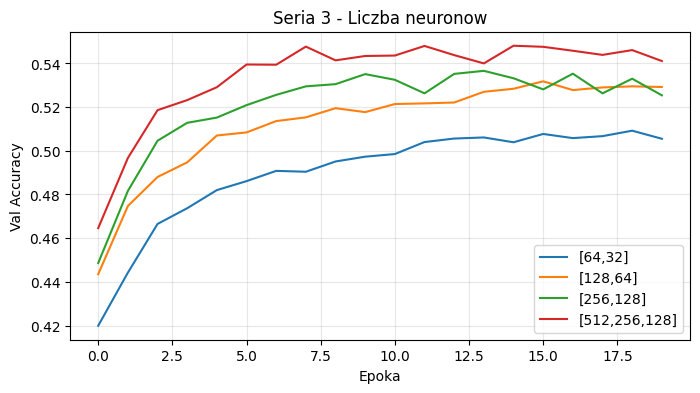

,hidden,max_val_acc
0,"[64,32]",0.5092
1,"[128,64]",0.5318
2,"[256,128]",0.5366
3,"[512,256,128]",0.5481


In [20]:
names = list(hidden_configs.keys())
plt.figure(figsize=(8, 4))
for name in names:
    plt.plot(hidden_results[name], label=name)
plt.title('Seria 3 - Liczba neuronow')
plt.xlabel('Epoka'); plt.ylabel('Val Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('plots/exp_neurony.png'); plt.show()

display(pd.DataFrame({'hidden': names,'max_val_acc': [round(max(hidden_results[n]), 4) for n in names]}))


**Wniosek:** Więcej neuronow = lepszy wynik. Siec [512,256,128] osiąga najwyższe accuracy. Mała sieć [64,32] jest zbyt płytka.

## 5. Najlepszy model

Na podstawie eksperymentow wybieram: lr=0.0001, batch=64, hidden=[512,256,128]

In [22]:
train_loader, test_loader = get_loaders(64)
best_model = MLP([512, 256, 128], dropout=0.3).to(device)
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(best_model.parameters(), lr=0.0001)

train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []

for epoch in range(1, 31):
    tl, ta = train_epoch(best_model, train_loader, criterion, optimizer)
    vl, va = eval_epoch(best_model, test_loader, criterion)
    train_loss_hist.append(tl); val_loss_hist.append(vl)
    train_acc_hist.append(ta);  val_acc_hist.append(va)
    if epoch % 5 == 0:
        print(f'Epoka {epoch:2d} | loss: {tl:.3f} | val_loss: {vl:.3f} | val_acc: {va:.3f}')

torch.save(best_model.state_dict(), 'best_model.pth')
print(f'Najlepsze val accuracy: {max(val_acc_hist):.4f}')


Epoka  5 | loss: 1.453 | val_loss: 1.385 | val_acc: 0.516
Epoka 10 | loss: 1.293 | val_loss: 1.296 | val_acc: 0.542
Epoka 15 | loss: 1.174 | val_loss: 1.262 | val_acc: 0.551
Epoka 20 | loss: 1.088 | val_loss: 1.242 | val_acc: 0.562
Epoka 25 | loss: 1.014 | val_loss: 1.235 | val_acc: 0.567
Epoka 30 | loss: 0.943 | val_loss: 1.243 | val_acc: 0.568
Najlepsze val accuracy: 0.5723


### Krzywe uczenia

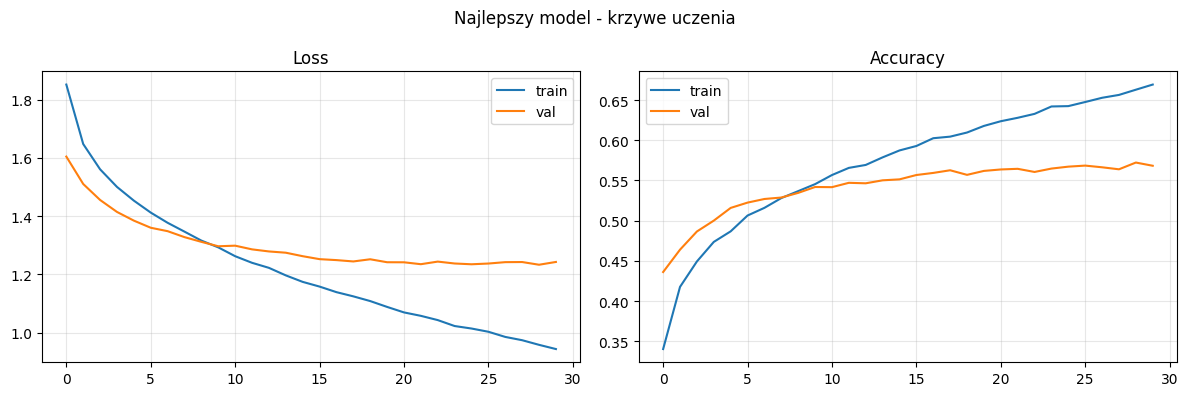

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_loss_hist, label='train'); ax1.plot(val_loss_hist, label='val')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(train_acc_hist, label='train'); ax2.plot(val_acc_hist, label='val')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('Najlepszy model - krzywe uczenia')
plt.tight_layout()
plt.savefig('plots/best_krzywe.png'); plt.show()


### Accuracy, Confusion Matrix, Classification Report

In [24]:
best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        preds = best_model(x.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print(f'Test accuracy: {(all_preds == all_labels).mean():.4f}')


Test accuracy: 0.5683


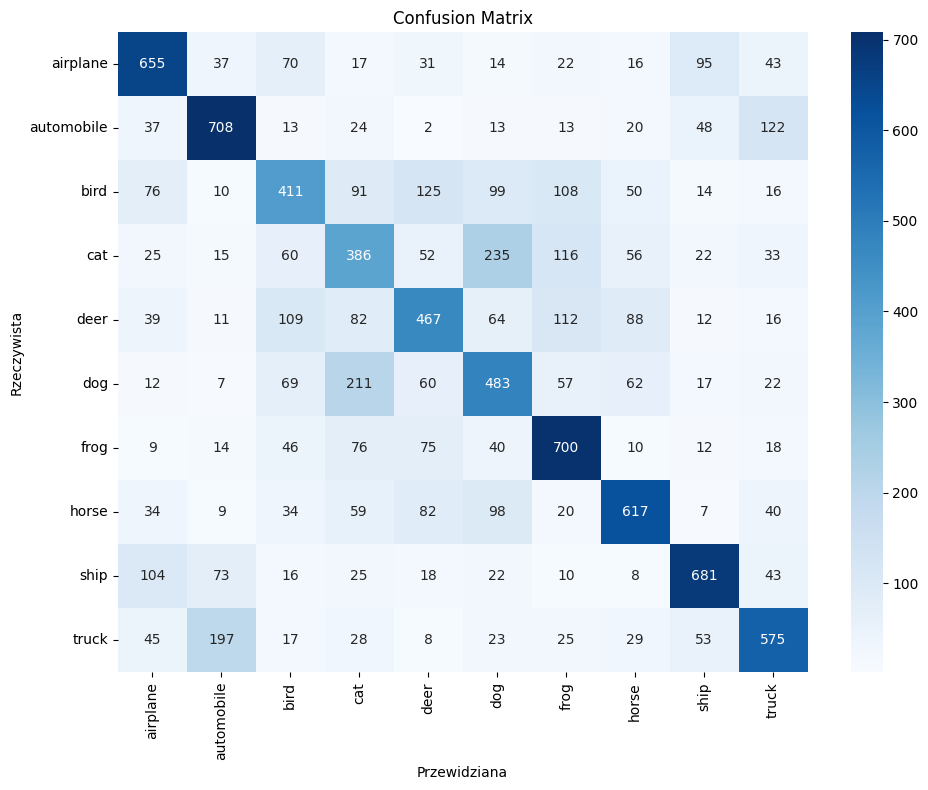

In [25]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Przewidziana'); plt.ylabel('Rzeczywista')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png'); plt.show()


In [26]:
print(classification_report(all_labels, all_preds, target_names=CLASSES))


              precision    recall  f1-score   support

    airplane       0.63      0.66      0.64      1000
  automobile       0.65      0.71      0.68      1000
        bird       0.49      0.41      0.45      1000
         cat       0.39      0.39      0.39      1000
        deer       0.51      0.47      0.49      1000
         dog       0.44      0.48      0.46      1000
        frog       0.59      0.70      0.64      1000
       horse       0.65      0.62      0.63      1000
        ship       0.71      0.68      0.69      1000
       truck       0.62      0.57      0.60      1000

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.57      0.57      0.57     10000



## 6. Wnioski

Siec MLP osiągneła około 50-55% accuracy. MLP nie jest idealną architektura do obrazów bo spłaszcza obraz i traci informację przestrzenną. Najgorzej klasyfikowane sa klasy wizualnie podobne (cat/dog)